Гипотеза 1. Обработка выбросов.

Замена значений, превыщающих 99-перцентиль, на медиану этого столбца. Предположительно это уменьшит шум и улучшить обобщающую способость модели

In [8]:
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

In [2]:
df_train = pd.read_csv('train_final_processed.csv')
df_test = pd.read_csv('test_final_processed.csv')

In [5]:
X_train_full = df_train.drop(['sk_id_curr', 'target'], axis=1)
y_train_full = df_train['target']

if y_train_full.dtype == 'object' or len(y_train_full.unique()) > 2:
    y_train_full = y_train_full.map({'0': 0, '1': 1}).fillna(0).astype(int)

common_cols = X_train_full.columns.intersection(df_test.drop(['sk_id_curr'], axis=1).columns)
if len(common_cols) < 10:
    print("Предупреждение")
X_train_full = X_train_full[common_cols]
df_test_processed = df_test[common_cols]

In [6]:
cat_cols = [col for col in common_cols if X_train_full[col].dtype == 'object']
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train_full[col] = X_train_full[col].astype(str).fillna('missing')
    df_test_processed[col] = df_test_processed[col].astype(str).fillna('missing')
    
    all_values = pd.concat([X_train_full[col], df_test_processed[col]], axis=0).unique()
    le.fit(all_values) 
    
    X_train_full[col] = le.transform(X_train_full[col])
    df_test_processed[col] = le.transform(df_test_processed[col])

C:\Users\klmv0\AppData\Local\Temp\ipykernel_17900\1254183696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col] = df_test_processed[col].astype(str).fillna('missing')
C:\Users\klmv0\AppData\Local\Temp\ipykernel_17900\1254183696.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col] = le.transform(df_test_processed[col])
C:\Users\klmv0\AppData\Local\Temp\ipykernel_17900\1254183696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

In [7]:
for col in X_train_full.select_dtypes(include=['float64', 'int64']).columns:
    percentile_99 = X_train_full[col].quantile(0.99)
    median_value = X_train_full[col].median()
    X_train_full[col] = X_train_full[col].apply(lambda x: median_value if x > percentile_99 else x)
    df_test_processed[col] = df_test_processed[col].apply(lambda x: median_value if x > percentile_99 else x)

C:\Users\klmv0\AppData\Local\Temp\ipykernel_17900\4081750730.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col] = df_test_processed[col].apply(lambda x: median_value if x > percentile_99 else x)
C:\Users\klmv0\AppData\Local\Temp\ipykernel_17900\4081750730.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col] = df_test_processed[col].apply(lambda x: median_value if x > percentile_99 else x)
C:\Users\klmv0\AppData\Local\Temp\ipykernel_17900\4081750730.py:5: Setting

In [9]:
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y)

In [10]:
cat_model_optimal = CatBoostClassifier(
    iterations=1000,     
    learning_rate=0.03,       
    depth=7,          
    auto_class_weights='SqrtBalanced',
    random_state=42,
    l2_leaf_reg=2,  
    eval_metric='AUC',
    loss_function='Logloss',
    verbose=100)

cat_model_optimal.fit(X_train, y_train, eval_set=(X_val, y_val), cat_features=cat_cols)

0:	test: 0.7010435	best: 0.7010435 (0)	total: 2.24s	remaining: 37m 15s
100:	test: 0.7609714	best: 0.7609714 (100)	total: 1m 50s	remaining: 16m 22s
200:	test: 0.7707828	best: 0.7707828 (200)	total: 3m 42s	remaining: 14m 45s
300:	test: 0.7751412	best: 0.7751412 (300)	total: 5m 35s	remaining: 12m 58s
400:	test: 0.7776698	best: 0.7776698 (400)	total: 7m 29s	remaining: 11m 11s
500:	test: 0.7804648	best: 0.7804674 (499)	total: 9m 21s	remaining: 9m 19s
600:	test: 0.7823566	best: 0.7823566 (600)	total: 11m 9s	remaining: 7m 24s
700:	test: 0.7832814	best: 0.7832814 (700)	total: 12m 50s	remaining: 5m 28s
800:	test: 0.7839404	best: 0.7839493 (798)	total: 14m 30s	remaining: 3m 36s
900:	test: 0.7842719	best: 0.7843187 (895)	total: 16m 14s	remaining: 1m 47s
999:	test: 0.7843805	best: 0.7844100 (995)	total: 17m 57s	remaining: 0us

bestTest = 0.7844100468
bestIteration = 995

Shrink model to first 996 iterations.


In [13]:
y_val_pred_proba = cat_model_optimal.predict_proba(X_val)[:, 1]
val_metrics = {
    'ROC-AUC': roc_auc_score(y_val, y_val_pred_proba),
    'Accuracy': accuracy_score(y_val, y_val_pred_proba > 0.5),
    'Precision': precision_score(y_val, y_val_pred_proba > 0.5),
    'Recall': recall_score(y_val, y_val_pred_proba > 0.5),
    'F1-Score': f1_score(y_val, y_val_pred_proba > 0.5)
}
for metric, value in val_metrics.items():
    print(f'Validation {metric}: {value:.4f}')

Validation ROC-AUC: 0.7844
Validation Accuracy: 0.9042
Validation Precision: 0.3662
Validation Recall: 0.2548
Validation F1-Score: 0.3005


In [14]:
test_pred_proba = cat_model_optimal.predict_proba(df_test_processed)[:, 1]
submission = pd.DataFrame({
    'sk_id_curr': df_test['sk_id_curr'],
    'target': test_pred_proba
})
submission.to_csv('submission_hypothesis_1.csv', index=False)

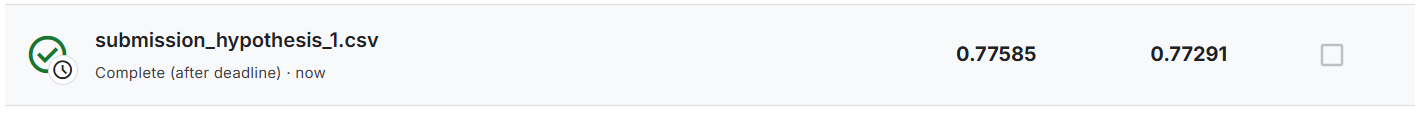

Т.к результаты стали хуже, я решила сделать другую обработку колонок, не включать 'sk_id_curr', 'target', 'sk_id_bureau', 'sk_id_prev'

In [15]:

train_processed = X_train_full.copy()
test_processed = df_test_processed.copy()

numerical_cols = X_train_full.select_dtypes(include=['float64', 'int64']).columns

cols_to_exclude = ['sk_id_curr', 'target', 'sk_id_bureau', 'sk_id_prev']
binary_cols = [col for col in numerical_cols if X_train_full[col].nunique() <= 2]

continuous_cols = [col for col in numerical_cols 
                  if col not in cols_to_exclude + binary_cols
                  and X_train_full[col].nunique() > 10]

print(f"Найдено {len(continuous_cols)} колонок для обработки выбросов")
print(f"Перцентиль: {0.99}")

total_outliers_train = 0
total_outliers_test = 0
processed_columns = []

Найдено 307 колонок для обработки выбросов
Перцентиль: 0.99


In [16]:
for col in continuous_cols:
    percentile_value = X_train_full[col].quantile(0.99)
    median_value = X_train_full[col].median()
    
    train_outliers = train_processed[col] > percentile_value
    test_outliers = test_processed[col] > percentile_value
    
    n_outliers_train = train_outliers.sum()
    n_outliers_test = test_outliers.sum()
    
    if n_outliers_train > 0 or n_outliers_test > 0:
        train_processed.loc[train_outliers, col] = median_value
        test_processed.loc[test_outliers, col] = median_value
        
        total_outliers_train += n_outliers_train
        total_outliers_test += n_outliers_test
        processed_columns.append(col)


print(f"Обработано колонок: {len(processed_columns)}")
print(f"Всего выбросов в train: {total_outliers_train}")
print(f"Всего выбросов в test: {total_outliers_test}")

Обработано колонок: 215
Всего выбросов в train: 567312
Всего выбросов в test: 105149


In [17]:
X_train_processed = train_processed
X_test_processed = test_processed

In [18]:
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y)

cat_model_optimal = CatBoostClassifier(
    iterations=1000,     
    learning_rate=0.03,       
    depth=7,          
    auto_class_weights='SqrtBalanced',
    random_state=42,
    l2_leaf_reg=2,  
    eval_metric='AUC',
    loss_function='Logloss',
    verbose=100)

cat_model_optimal.fit(X_train, y_train, eval_set=(X_val, y_val), cat_features=cat_cols)


0:	test: 0.7010435	best: 0.7010435 (0)	total: 1.06s	remaining: 17m 42s
100:	test: 0.7609714	best: 0.7609714 (100)	total: 1m 39s	remaining: 14m 41s
200:	test: 0.7707828	best: 0.7707828 (200)	total: 3m 19s	remaining: 13m 13s
300:	test: 0.7751412	best: 0.7751412 (300)	total: 4m 58s	remaining: 11m 32s
400:	test: 0.7776698	best: 0.7776698 (400)	total: 7m 19s	remaining: 10m 56s
500:	test: 0.7804648	best: 0.7804674 (499)	total: 9m 5s	remaining: 9m 2s
600:	test: 0.7823566	best: 0.7823566 (600)	total: 10m 49s	remaining: 7m 11s
700:	test: 0.7832814	best: 0.7832814 (700)	total: 12m 46s	remaining: 5m 27s
800:	test: 0.7839404	best: 0.7839493 (798)	total: 14m 37s	remaining: 3m 38s
900:	test: 0.7842719	best: 0.7843187 (895)	total: 16m 27s	remaining: 1m 48s
999:	test: 0.7843805	best: 0.7844100 (995)	total: 18m 9s	remaining: 0us

bestTest = 0.7844100468
bestIteration = 995

Shrink model to first 996 iterations.


In [ ]:
y_val_pred_proba = cat_model_optimal.predict_proba(X_val)[:, 1]
val_metrics = {
    'ROC-AUC': roc_auc_score(y_val, y_val_pred_proba),
    'Accuracy': accuracy_score(y_val, y_val_pred_proba > 0.5),
    'Precision': precision_score(y_val, y_val_pred_proba > 0.5),
    'Recall': recall_score(y_val, y_val_pred_proba > 0.5),
    'F1-Score': f1_score(y_val, y_val_pred_proba > 0.5)
}
for metric, value in val_metrics.items():
    print(f'Validation {metric}: {value:.4f}')

Validation ROC-AUC: 0.7844
Validation Accuracy: 0.9042
Validation Precision: 0.3662
Validation Recall: 0.2548
Validation F1-Score: 0.3005


In [22]:
test_pred_proba = cat_model_optimal.predict_proba(df_test_processed)[:, 1]
submission = pd.DataFrame({
    'sk_id_curr': df_test['sk_id_curr'],
    'target': test_pred_proba
})
submission.to_csv('submission_hypothesis_1_2.csv', index=False)

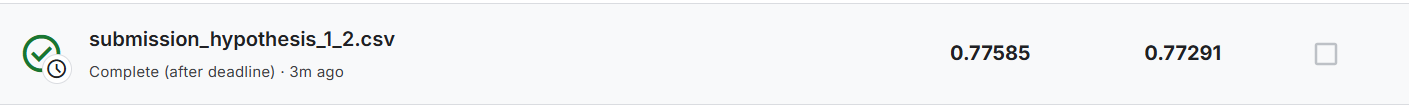

Так как и здесь мы не видим изминений, предлагаю сделать порог в 95 перцентиль вместо 99

In [ ]:

train_processed = X_train_full.copy()
test_processed = df_test_processed.copy()

numerical_cols = X_train_full.select_dtypes(include=['float64', 'int64']).columns

cols_to_exclude = ['sk_id_curr', 'target', 'sk_id_bureau', 'sk_id_prev']
binary_cols = [col for col in numerical_cols if X_train_full[col].nunique() <= 2]

continuous_cols = [col for col in numerical_cols 
                  if col not in cols_to_exclude + binary_cols
                  and X_train_full[col].nunique() > 10]

print(f"Найдено {len(continuous_cols)} колонок для обработки выбросов")
print(f"Перцентиль: {0.95}")

total_outliers_train = 0
total_outliers_test = 0
processed_columns = []

for col in continuous_cols:
    percentile_value = X_train_full[col].quantile(0.95)
    median_value = X_train_full[col].median()
    
    train_outliers = train_processed[col] > percentile_value
    test_outliers = test_processed[col] > percentile_value
    
    n_outliers_train = train_outliers.sum()
    n_outliers_test = test_outliers.sum()
    
    if n_outliers_train > 0 or n_outliers_test > 0:
        train_processed.loc[train_outliers, col] = median_value
        test_processed.loc[test_outliers, col] = median_value
        
        total_outliers_train += n_outliers_train
        total_outliers_test += n_outliers_test
        processed_columns.append(col)


print(f"Обработано колонок: {len(processed_columns)}")
print(f"Всего выбросов в train: {total_outliers_train}")
print(f"Всего выбросов в test: {total_outliers_test}")

X_train_processed = train_processed
X_test_processed = test_processed

Найдено 307 колонок для обработки выбросов
Перцентиль: 0.99
Обработано колонок: 246
Всего выбросов в train: 3099213
Всего выбросов в test: 562579


In [24]:
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y)

cat_model_optimal = CatBoostClassifier(
    iterations=1000,     
    learning_rate=0.03,       
    depth=7,          
    auto_class_weights='SqrtBalanced',
    random_state=42,
    l2_leaf_reg=2,  
    eval_metric='AUC',
    loss_function='Logloss',
    verbose=100)

cat_model_optimal.fit(X_train, y_train, eval_set=(X_val, y_val), cat_features=cat_cols)


0:	test: 0.7010435	best: 0.7010435 (0)	total: 1.15s	remaining: 19m 10s
100:	test: 0.7609714	best: 0.7609714 (100)	total: 1m 44s	remaining: 15m 30s
200:	test: 0.7707828	best: 0.7707828 (200)	total: 3m 23s	remaining: 13m 28s
300:	test: 0.7751412	best: 0.7751412 (300)	total: 5m 18s	remaining: 12m 20s
400:	test: 0.7776698	best: 0.7776698 (400)	total: 6m 58s	remaining: 10m 24s
500:	test: 0.7804648	best: 0.7804674 (499)	total: 8m 39s	remaining: 8m 37s
600:	test: 0.7823566	best: 0.7823566 (600)	total: 10m 39s	remaining: 7m 4s
700:	test: 0.7832814	best: 0.7832814 (700)	total: 12m 22s	remaining: 5m 16s
800:	test: 0.7839404	best: 0.7839493 (798)	total: 14m 3s	remaining: 3m 29s
900:	test: 0.7842719	best: 0.7843187 (895)	total: 16m 2s	remaining: 1m 45s
999:	test: 0.7843805	best: 0.7844100 (995)	total: 17m 44s	remaining: 0us

bestTest = 0.7844100468
bestIteration = 995

Shrink model to first 996 iterations.


In [25]:
y_val_pred_proba = cat_model_optimal.predict_proba(X_val)[:, 1]
val_metrics = {
    'ROC-AUC': roc_auc_score(y_val, y_val_pred_proba),
    'Accuracy': accuracy_score(y_val, y_val_pred_proba > 0.5),
    'Precision': precision_score(y_val, y_val_pred_proba > 0.5),
    'Recall': recall_score(y_val, y_val_pred_proba > 0.5),
    'F1-Score': f1_score(y_val, y_val_pred_proba > 0.5)
}
for metric, value in val_metrics.items():
    print(f'Validation {metric}: {value:.4f}')

Validation ROC-AUC: 0.7844
Validation Accuracy: 0.9042
Validation Precision: 0.3662
Validation Recall: 0.2548
Validation F1-Score: 0.3005


In [26]:
test_pred_proba = cat_model_optimal.predict_proba(df_test_processed)[:, 1]
submission = pd.DataFrame({
    'sk_id_curr': df_test['sk_id_curr'],
    'target': test_pred_proba
})
submission.to_csv('submission_hypothesis_1_3.csv', index=False)

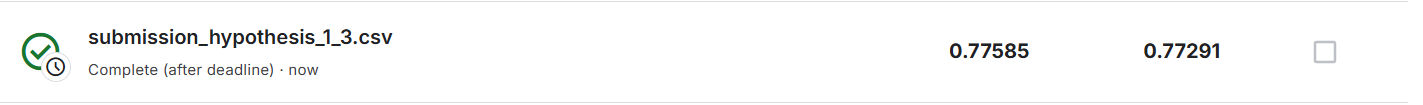

Видим, что никаких изминений не происходит, поэтому заканчиваем с этой гипотезой.